# Interest Rate Prediction: Risk-Based Pricing on Lending Club Data

Notebook 1 asked whether a borrower will default. This notebook asks what interest rate they should pay — the risk-based pricing problem.

Interest rate prediction is a natural complement to default classification. If a model can reconstruct Lending Club's pricing decisions from raw borrower data, it validates that the rates were genuinely risk-based. More interestingly, the features that drive rate prediction should mirror the features that drive default — and comparing the two SHAP analyses tells a richer story about credit risk than either notebook alone.

The same constraint applies: 

>`grade` and `sub_grade` are excluded. The same 2017–2019 vintage is used. The same preprocessing pipeline carries forward unchanged.

## Setup & Data Loading

### Imports

In [1]:
# General Utilities
from pathlib import Path
import joblib
import json
import numpy as np

# Sci-Kit Learn Imports
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.utils.class_weight import compute_sample_weight

# XGBoost
from xgboost import XGBRegressor

# Local Package Imports (fintech_ml)
from banking_ml.utils import (
    load_data,
    inspect_dataframe,
    save_data_summary_tables,
    clean_raw_data,
    assess_features,
    filter_by_vintage,
)

from banking_ml.preprocessing import (
    drop_high_missingness,
    drop_leakage_columns,
    split_data,
    select_core_features_regression,
)

from banking_ml.feature_engineering import (
    engineer_features,
)

from banking_ml.visualization import (
    plot_default_rate_by_category,
    plot_correlation_heatmap,
    plot_missingness,
    plot_feature_target_correlation,
    plot_target_distribution,
    plot_residuals,
    plot_predicted_vs_actual,
)

from banking_ml.pipelines import (
    build_pipeline,
)

from banking_ml.evaluation import (
    evaluate_regressor,
    compare_regressors,
)

from banking_ml.explainability import (
    get_shap_values,
    plot_shap_summary,
    plot_shap_beeswarm,
)

from banking_ml.models import (
    tune_model,
    display_best_params,
    get_xgb_regression_param_grid,
)

### Paths

In [2]:
# Project Root
PROJECT_ROOT = Path.cwd().parent.resolve()

# Data Path
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Artifacts Base Directory
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

# Pricing Artifacts
PRICING_DIR = ARTIFACTS_DIR / "pricing"

# EDA
EDA_FIGURES_DIR = PRICING_DIR / "eda" / "figures"
EDA_TABLES_DIR = PRICING_DIR / "eda" / "tables"

# Models
MODELS_DIR = PRICING_DIR / "models"
FIGURES_DIR = MODELS_DIR / "figures"
TABLES_DIR = MODELS_DIR / "tables"
PARAMS_DIR = MODELS_DIR / "params"

# Create all directories if missing
for d in [
    EDA_FIGURES_DIR,
    EDA_TABLES_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    PARAMS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

### Load Dataset


Same 2017–2019 vintage as notebook 1 — post-crisis, pre-COVID, representative of normal lending conditions. The full dataset spans 2007–2020 but filtering to this window keeps the credit environment consistent and the dataset tractable.

In [3]:
DATA_LOAD_PATH = DATA_DIR / "Loan_status_2007-2020Q3.gzip"

df = load_data(DATA_LOAD_PATH)
df = filter_by_vintage(df, start_year=2017, end_year=2019)

Vintage filter: 2017 – 2019
Filtered dataset shape: (1456928, 141)


### Clean Raw Data

In [4]:
df = clean_raw_data(df)
df.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
230717,0,120122535,12000.0,12000.0,12000.0,36 months,7.97,375.88,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
230718,1,119374887,32000.0,32000.0,32000.0,36 months,11.99,1062.71,B,B5,...,Apr-2020,Jun-2020,Apr-2020,2.0,0.0,ACTIVE,123.08000,6189.66,1062.71,N
230719,2,119321612,40000.0,40000.0,40000.0,60 months,15.05,952.65,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
230720,3,120122034,16000.0,16000.0,16000.0,36 months,7.97,501.17,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
230721,4,118659541,33000.0,33000.0,33000.0,36 months,7.21,1022.12,A,A3,...,Feb-2020,Apr-2020,Feb-2020,3.0,21.0,DELINQUENT,177.96231,10197.78,59.68,N


## Initial Data Inspection

### Dataset Overview


The raw dataset arrives with the same 141 columns as notebook 1. The preprocessing pipeline is identical up to feature selection — the only meaningful difference is that `int_rate` moves from a feature to the target.

In [5]:
inspect_dataframe(df)

DATAFRAME SUMMARY

Shape: 1,456,928 rows x 141 columns

Dtype breakdown:
float64    108
str         32
int64        1

Duplicate rows: 0

Columns with missing values: 52 of 141
hardship_loan_status                          91.77
deferral_term                                 91.76
hardship_status                               91.76
hardship_type                                 91.76
hardship_dpd                                  91.76
hardship_length                               91.76
payment_plan_start_date                       91.76
hardship_end_date                             91.76
hardship_start_date                           91.76
hardship_reason                               91.76
orig_projected_additional_accrued_interest    89.67
hardship_last_payment_amount                  89.59
hardship_amount                               89.59
hardship_payoff_balance_amount                89.59
verification_status_joint                     88.35
sec_app_revol_util                         

### Missingness


A single missingness pass is sufficient here. Unlike notebook 1 there is no binary target encoding step that filters out unresolved loans — `int_rate` is present for all originated loans, so the missingness profile doesn't change during preprocessing.

In [6]:
df_clean = drop_high_missingness(df)

Dropping 34 columns above 50% missing threshold:
  mths_since_last_delinq: 54.4%
  mths_since_last_record: 86.7%
  mths_since_last_major_derog: 76.2%
  annual_inc_joint: 87.4%
  dti_joint: 87.4%
  verification_status_joint: 88.3%
  mths_since_recent_bc_dlq: 79.2%
  mths_since_recent_revol_delinq: 69.7%
  revol_bal_joint: 87.7%
  sec_app_fico_range_low: 87.7%
  sec_app_fico_range_high: 87.7%
  sec_app_earliest_cr_line: 87.7%
  sec_app_inq_last_6mths: 87.7%
  sec_app_mort_acc: 87.7%
  sec_app_open_acc: 87.7%
  sec_app_revol_util: 87.9%
  sec_app_open_act_il: 87.7%
  sec_app_num_rev_accts: 87.7%
  sec_app_chargeoff_within_12_mths: 87.7%
  sec_app_collections_12_mths_ex_med: 87.7%
  hardship_type: 91.8%
  hardship_reason: 91.8%
  hardship_status: 91.8%
  deferral_term: 91.8%
  hardship_amount: 89.6%
  hardship_start_date: 91.8%
  hardship_end_date: 91.8%
  payment_plan_start_date: 91.8%
  hardship_length: 91.8%
  hardship_dpd: 91.8%
  hardship_loan_status: 91.8%
  orig_projected_additional

## Target Variable Definition

### Target Distribution


Interest rates range from roughly 6% to 31% with a mean around 13% — right-skewed, reflecting the larger volume of lower-risk loans in the portfolio. The distribution is multimodal with visible rate tiers, a pattern that will become important when interpreting model performance.

In [7]:
print(f"Target: int_rate")
print(f"Mean:   {df_clean['int_rate'].mean():.2f}%")
print(f"Median: {df_clean['int_rate'].median():.2f}%")
print(f"Std:    {df_clean['int_rate'].std():.2f}%")
print(f"Min:    {df_clean['int_rate'].min():.2f}%")
print(f"Max:    {df_clean['int_rate'].max():.2f}%")
print(f"Nulls:  {df_clean['int_rate'].isnull().sum()}")

Target: int_rate
Mean:   12.94%
Median: 12.13%
Std:    5.10%
Min:    5.31%
Max:    30.99%
Nulls:  0


### Drop Leakage Features


The same post-origination columns removed in notebook 1 are removed here. One additional consideration: `loan_status` is not removed since it was never a feature in this notebook — but it's also not the target, so it will be naturally excluded during feature selection.

In [8]:
df_clean = drop_leakage_columns(df_clean)

Dropping 18 leakage columns
Dropping 7 administrative columns
Total dropped: 25
Remaining columns: 82


### Raw Data Summary

In [9]:
save_data_summary_tables(df_clean, "int_rate", EDA_TABLES_DIR / "raw")

Data summary tables saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/tables/raw/missing_values.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/tables/raw/feature_stats.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/tables/raw/target_distribution.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/tables/raw/categorical_counts.csv


## Exploratory Data Analysis


With `int_rate` as the target, the EDA question shifts from "what predicts default?" to "what predicts the rate a borrower receives?" The correlation patterns should be similar — Lending Club's rates were risk-based — but the relative importance of features may differ.

### Interest Rate Distribution


The multimodal distribution confirms what the residual plots will later show — Lending Club assigned rates in discrete tiers rather than as a continuous function. This is a property of the target variable that directly constrains how well any regression model can perform.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/figures/01_int_rate_distribution.png


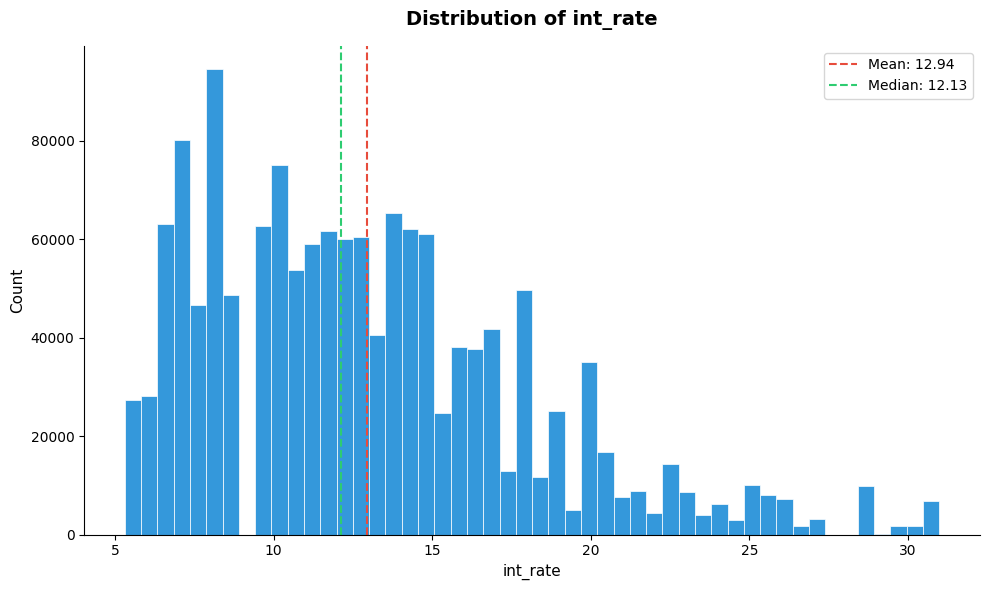

In [10]:
plot_target_distribution(
    df_clean,
    target_col="int_rate",
    save_path=EDA_FIGURES_DIR / "01_int_rate_distribution.png"
)

### Rate by Category


Term is the strongest categorical predictor — 60-month loans carry meaningfully higher rates than 36-month loans, reflecting the additional duration risk. Purpose shows clear variation, with small business and moving loans at the higher end and major purchase and car loans at the lower end. Home ownership shows modest but consistent differences.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/figures/02_rate_by_category.png


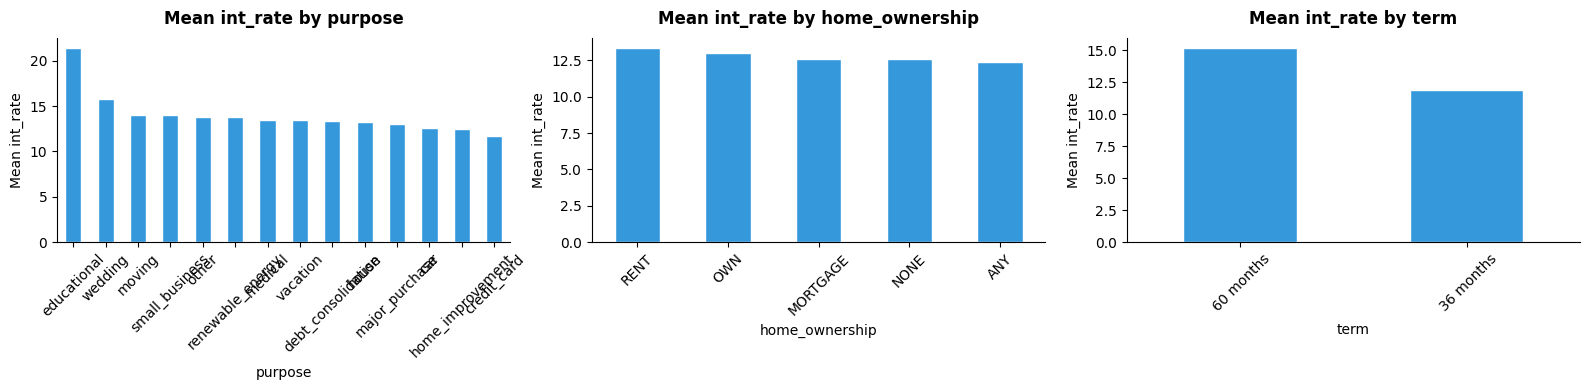

In [11]:
CAT_COLS = ["purpose", "home_ownership", "term"]

plot_default_rate_by_category(
    df_clean,
    cat_cols=CAT_COLS,
    target_col="int_rate",
    save_path=EDA_FIGURES_DIR / "02_rate_by_category.png"
)

### Numeric Correlations with Rate


Utilization features dominate the positive correlations — `all_util`, `bc_util`, and `revol_util` all show strong positive relationships with rate. FICO scores show the strongest negative correlation at -0.416, confirming that credit quality is the primary driver of Lending Club's pricing decisions.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/figures/03_correlation_heatmap.png


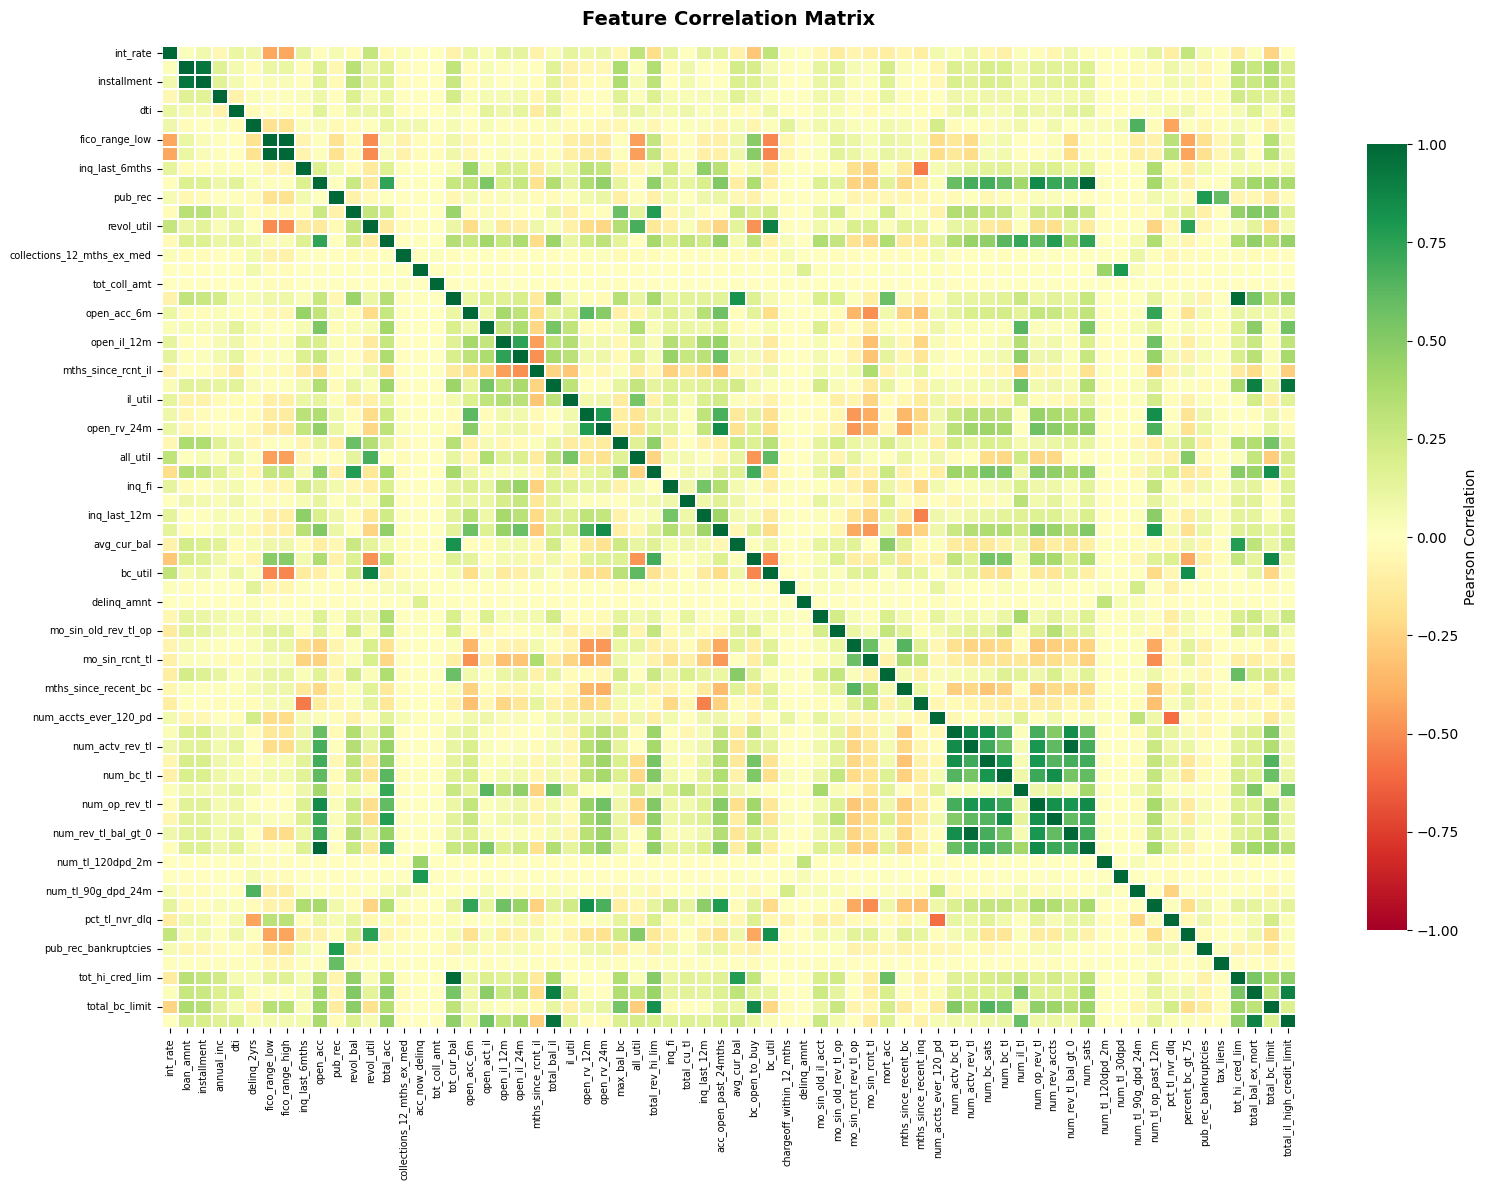

In [12]:
plot_correlation_heatmap(
    df_clean,
    target_col="int_rate",
    save_path=EDA_FIGURES_DIR / "03_correlation_heatmap.png"
)

### Missingness

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/figures/04_missingness.png


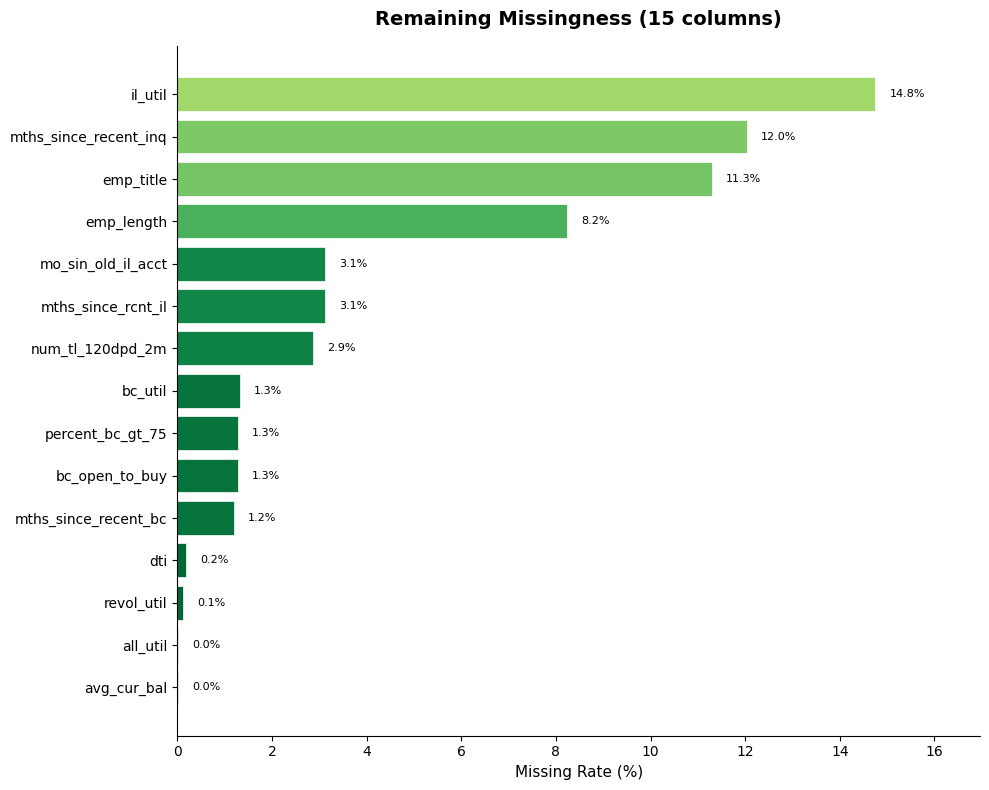

In [13]:
plot_missingness(
    df_clean,
    save_path=EDA_FIGURES_DIR / "04_missingness.png"
)

### Feature Correlation with Target


FICO scores sit at -0.416 — the strongest signal in the dataset and the clearest validation that Lending Club's pricing was credit-quality driven. The utilization cluster (`all_util`, `bc_util`, `percent_bc_gt_75`, `revol_util`) forms a tight positive correlation band around 0.28-0.30, confirming that leverage stress is the second major pricing factor. These patterns will recur in the SHAP analysis.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/figures/05_feature_target_correlation.png


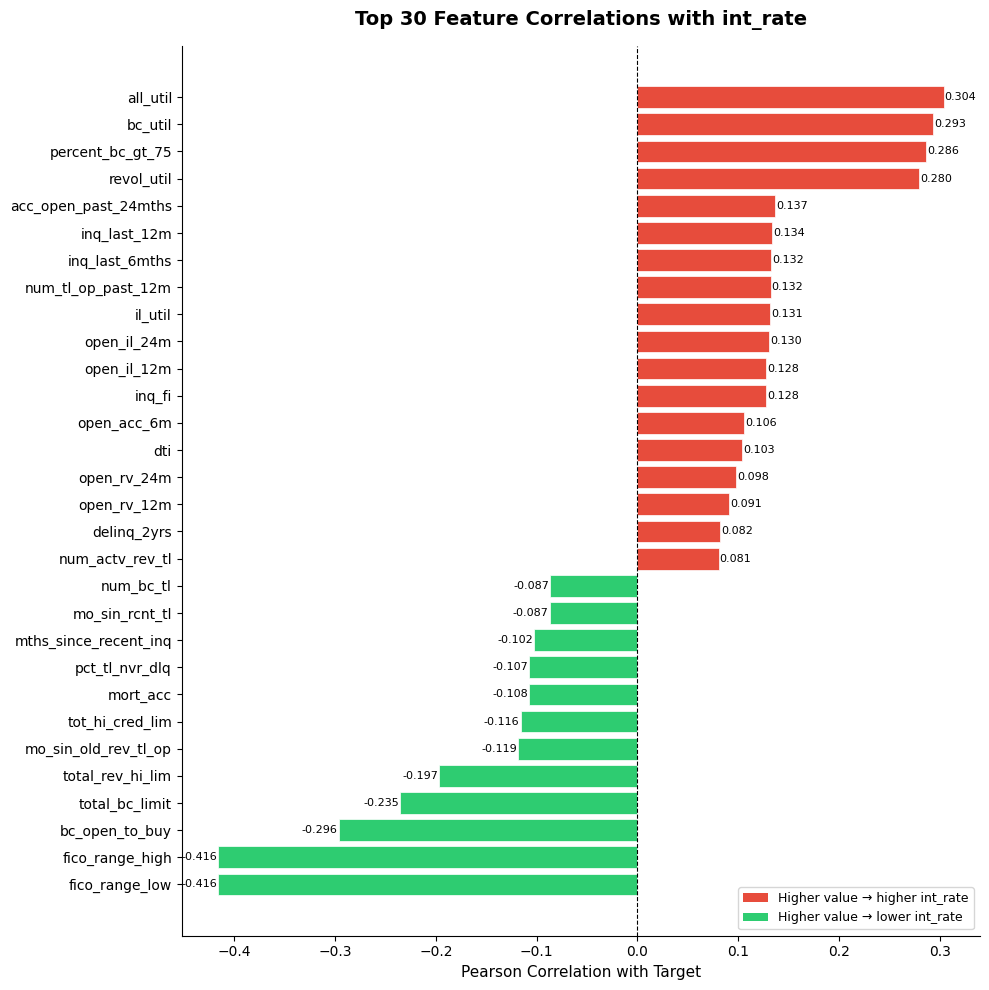

In [14]:
plot_feature_target_correlation(
    df_clean,
    target_col="int_rate",
    top_n=30,
    save_path=EDA_FIGURES_DIR / "05_feature_target_correlation.png"
)

## Feature Engineering & Selection

### Engineer Features

In [15]:
df_clean = engineer_features(df_clean)
print(df_clean.shape)

Created: credit_age_months
Applied: _add_burden_ratios -> added features: ['loan_to_income', 'payment_to_income', 'revol_bal_to_income']
Applied: _add_utilization_composite -> added features: ['utilization_composite']
Applied: _add_derogatory_score -> added features: ['derogatory_score']
Applied: _add_credit_velocity -> added features: ['credit_velocity', 'seasoning_ratio']
Applied: _add_rate_features -> added features: ['rate_to_dti', 'rate_to_income', 'rate_utilization_stress', 'affordability_gap']
Applied: _add_fico_features -> added features: ['fico_dti_risk']
Dropped 4 features: ['emp_title', 'earliest_cr_line', 'grade', 'sub_grade']
Shape after feature engineering: (1456928, 92)
(1456928, 92)



The same feature engineering pipeline from notebook 1 runs here — burden ratios, utilization composite, derogatory score, FICO features, and credit velocity. Two features are excluded from the regression feature set that were present in classification: `payment_to_income` and `rate_to_dti` are both derived from `int_rate` and would constitute leakage.

### Select Core Features


Feature selection lands on 26 features — slightly leaner than notebook 1 due to leakage removal. The assess_features report below confirms no remaining redundancy after dropping revol_util in favor of utilization_composite.

In [16]:
df_clean = select_core_features_regression(df_clean)

Selecting 26 core features and the target


### Assess Features

In [17]:
assessment = assess_features(df_clean, "int_rate")

  FEATURE ASSESSMENT REPORT

Total numeric features assessed: 19

Zero variance features (0): None

Low variance features below 0.01 (0):
  None

Highly correlated pairs above 0.85 (0):
  None


### Clean Data Summary

In [18]:
save_data_summary_tables(df_clean, "int_rate", EDA_TABLES_DIR / "clean")

Data summary tables saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/tables/clean/missing_values.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/tables/clean/feature_stats.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/tables/clean/target_distribution.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/eda/tables/clean/categorical_counts.csv


## Features and Target

### Define Features and Target

In [19]:
X = df_clean.drop(columns=["int_rate"])
y = df_clean["int_rate"]

### Train / Test Split

In [20]:
X_train, X_test, y_train, y_test = split_data(X, y)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train mean rate: {y_train.mean():.2f}%")
print(f"y_test mean rate:  {y_test.mean():.2f}%")

X_train: (1165542, 26)
X_test:  (291386, 26)
y_train mean rate: 12.94%
y_test mean rate:  12.94%


## Baseline Modeling

Three architectures establish the baseline — **Ridge regression** as a linear benchmark, **HistGradientBoosting** as sklearn's native tree ensemble, and **XGBoost** as the industry standard. 

The same comparison logic as notebook 1 applies: 
>Does model complexity matter on this feature set?

### Ridge Regression

#### Configuration & Training

In [21]:
ridge_pipeline = build_pipeline(
    Ridge(alpha=1.0, random_state=42),
    X_train
)

ridge_pipeline.fit(X_train, y_train)

joblib.dump(ridge_pipeline, PARAMS_DIR / "ridge_pipeline.joblib")
print(f"\n Artifact saved:")
print(f"  {PARAMS_DIR / 'ridge_pipeline.joblib'}")


 Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/params/ridge_pipeline.joblib


#### Evaluation

In [22]:
ridge_metrics = evaluate_regressor(ridge_pipeline, X_test, y_test, "Ridge Regression")

with open(TABLES_DIR / "ridge_metrics.json", "w") as f:
    json.dump(ridge_metrics, f, indent=2)


  Ridge Regression — Regression Evaluation
  RMSE:       3.9494  (lower is better)
  MAE:        2.9971  (lower is better)
  R²:         0.4014  (higher is better)
  Max Error:  23.3147



### Gradient Boosting Regressor

#### Configuration & Training

In [23]:
gb_pipeline = build_pipeline(
    HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),
    X_train
)

gb_pipeline.fit(X_train, y_train)

joblib.dump(gb_pipeline, PARAMS_DIR / "gb_pipeline.joblib")
print(f"\n Artifact saved:")
print(f"  {PARAMS_DIR / 'gb_pipeline.joblib'}")


 Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/params/gb_pipeline.joblib


#### Evaluation

In [24]:
gb_metrics = evaluate_regressor(gb_pipeline, X_test, y_test, "Gradient Boosting")

with open(TABLES_DIR / "gb_metrics.json", "w") as f:
    json.dump(gb_metrics, f, indent=2)


  Gradient Boosting — Regression Evaluation
  RMSE:       3.7604  (lower is better)
  MAE:        2.8176  (lower is better)
  R²:         0.4573  (higher is better)
  Max Error:  22.0239



### XGBoost Regressor

#### Configuration & Training

In [25]:
xgb_pipeline = build_pipeline(
    XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ),
    X_train
)

xgb_pipeline.fit(X_train, y_train)

joblib.dump(xgb_pipeline, PARAMS_DIR / "xgb_pipeline.joblib")
print(f"\n Artifact saved:")
print(f"  {PARAMS_DIR / 'xgb_pipeline.joblib'}")


 Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/params/xgb_pipeline.joblib


#### Evaluation

In [26]:
xgb_metrics = evaluate_regressor(xgb_pipeline, X_test, y_test, "XGBoost")

with open(TABLES_DIR / "xgb_metrics.json", "w") as f:
    json.dump(xgb_metrics, f, indent=2)


  XGBoost — Regression Evaluation
  RMSE:       3.7584  (lower is better)
  MAE:        2.8161  (lower is better)
  R²:         0.4579  (higher is better)
  Max Error:  21.9541



### Baseline Comparison


The tree models outperform Ridge meaningfully — R² of 0.45 versus 0.40 — confirming that interest rate pricing has nonlinear structure that a linear model can't capture. Gradient Boosting and XGBoost are essentially tied, consistent with the pattern in notebook 1. XGBoost is selected for tuning.

In [27]:
summary = compare_regressors([ridge_metrics, gb_metrics, xgb_metrics])
summary.to_csv(TABLES_DIR / "baseline_model_comparison.csv")

print(summary)
print(f"\n Artifact saved:")
print(f"  {TABLES_DIR / 'baseline_model_comparison.csv'}")

                     rmse     mae      r2  max_error
model                                               
XGBoost            3.7584  2.8161  0.4579    21.9541
Gradient Boosting  3.7604  2.8176  0.4573    22.0239
Ridge Regression   3.9494  2.9971  0.4014    23.3147

 Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/tables/baseline_model_comparison.csv


### Residual Plots


All three models show diagonal banding in the residuals — a signature of Lending Club's discrete rate tier structure. The model predicts a continuous value but the actual target is discretized, creating systematic residual patterns at each tier boundary. The tree models show tighter, more symmetric residuals than Ridge, particularly in the 5-15% rate range where loan volume is highest.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/figures/01_ridge_residuals.png


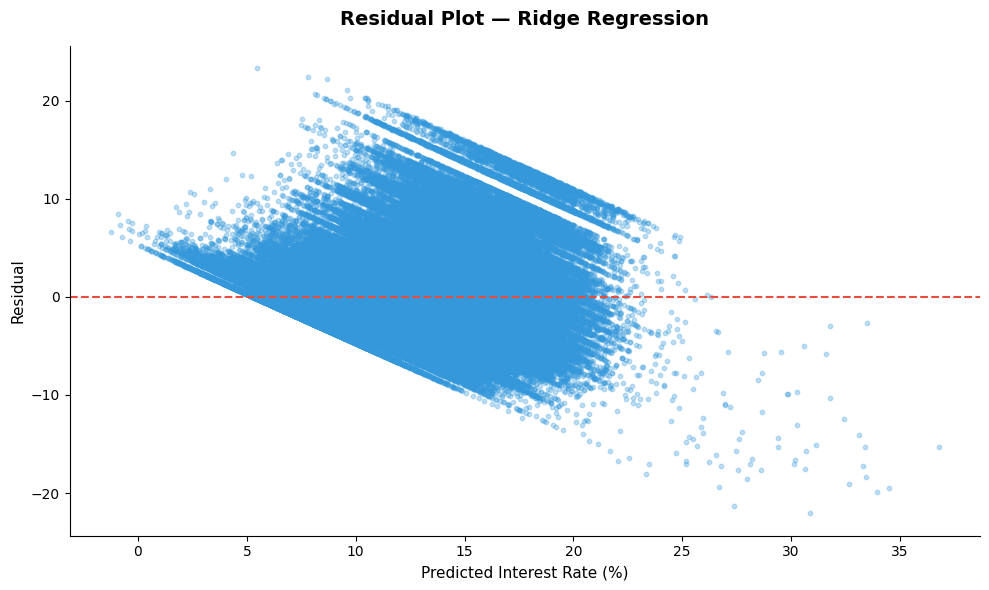

In [28]:
plot_residuals(
    ridge_pipeline, X_test, y_test, "Ridge Regression",
    save_path=FIGURES_DIR / "01_ridge_residuals.png"
)

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/figures/02_gb_residuals.png


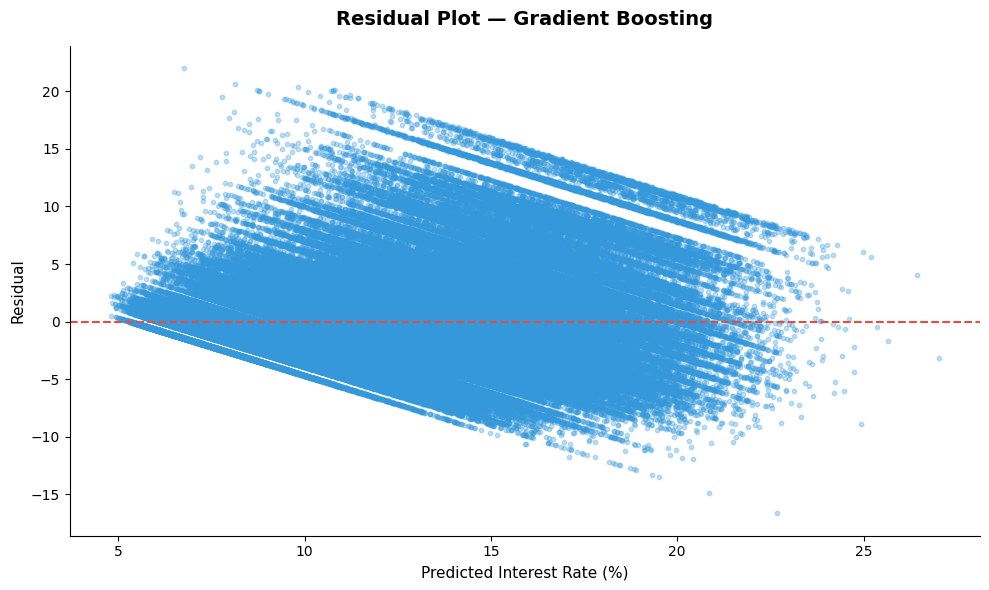

In [29]:
plot_residuals(
    gb_pipeline, X_test, y_test, "Gradient Boosting",
    save_path=FIGURES_DIR / "02_gb_residuals.png"
)

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/figures/03_xgb_residuals.png


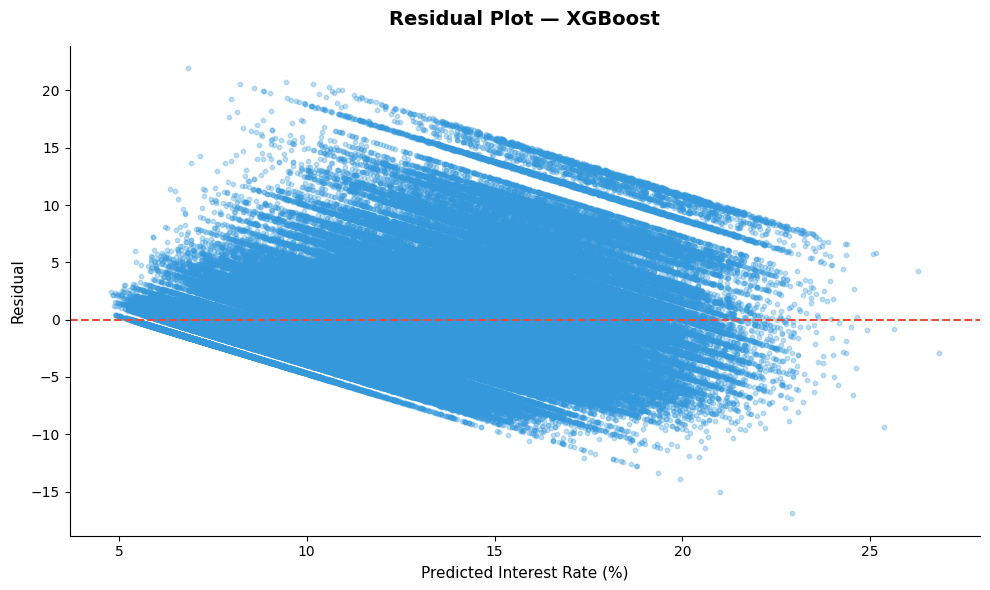

In [30]:
plot_residuals(
    xgb_pipeline, X_test, y_test, "XGBoost",
    save_path=FIGURES_DIR / "03_xgb_residuals.png"
)

## Hyperparameter Optimization


Same tuning approach as notebook 1 — RandomizedSearchCV across tree depth, learning rate, subsampling, and regularization parameters. Scoring uses negative RMSE rather than AUC since this is a regression 
problem. Three-fold cross-validation on the training set.

### Search Configuration

In [31]:
search = tune_model(
    xgb_pipeline,
    X_train,
    y_train,
    param_grid=get_xgb_regression_param_grid(),
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    use_sample_weights=False,
)

# Extract best estimator
best_xgb_pipeline = search.best_estimator_

joblib.dump(best_xgb_pipeline, PARAMS_DIR / "best_xgb_pipeline.joblib")
print(f"\n Artifact saved:")
print(f"  {PARAMS_DIR / 'best_xgb_pipeline.joblib'}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

  TUNING RESULTS
  Best CV neg_root_mean_squared_error: -3.6673
  Best parameters:
    model__subsample: 0.7
    model__reg_lambda: 1.5
    model__reg_alpha: 0
    model__n_estimators: 700
    model__min_child_weight: 1
    model__max_depth: 4
    model__learning_rate: 0.1
    model__gamma: 0
    model__colsample_bytree: 0.8

 Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/params/best_xgb_pipeline.joblib


### Best Parameters


The tuner favored a higher learning rate (0.1) and more estimators (700) than the classification model, with stronger L2 regularization (reg_lambda 1.5). The deeper search found that faster learning with more trees and stronger regularization outperforms the slower, shallower baseline configuration on this target.

In [32]:
display_best_params(search.best_params_)

,Value
subsample,0.7
reg_lambda,1.5
reg_alpha,0.0
n_estimators,700.0
min_child_weight,1.0
max_depth,4.0
learning_rate,0.1
gamma,0.0
colsample_bytree,0.8


### Evaluation

In [33]:
tuned_xgb_metrics = evaluate_regressor(best_xgb_pipeline, X_test, y_test, "XGBoost (Tuned)")

with open(TABLES_DIR / "tuned_xgb_metrics.json", "w") as f:
    json.dump(tuned_xgb_metrics, f, indent=2)


  XGBoost (Tuned) — Regression Evaluation
  RMSE:       3.6590  (lower is better)
  MAE:        2.7351  (lower is better)
  R²:         0.4862  (higher is better)
  Max Error:  21.5722



## Final Model Evaluation

### Final Model Comparison

Tuning delivered meaningful improvement — R² from 0.4538 to 0.4838, RMSE from 3.77 to 3.67. The tuned model explains 48% of variance in interest rates using only borrower fundamentals and no proprietary Lending Club grades.

The R² ceiling here is a feature of the problem, not a model limitation. Lending Club assigned rates in discrete tiers based on an internal scoring formula that incorporated grade and sub_grade — features we deliberately excluded. The remaining unexplained variance is largely the gap between the continuous borrower risk profile and the discrete rate bucket it maps to.

In [34]:
summary_tuned = compare_regressors([ridge_metrics, gb_metrics, xgb_metrics, tuned_xgb_metrics])
summary_tuned.to_csv(TABLES_DIR / "tuned_model_comparison.csv")

print(summary_tuned)
print(f"\n Artifact saved:")
print(f"  {TABLES_DIR / 'tuned_model_comparison.csv'}")

                     rmse     mae      r2  max_error
model                                               
XGBoost (Tuned)    3.6590  2.7351  0.4862    21.5722
XGBoost            3.7584  2.8161  0.4579    21.9541
Gradient Boosting  3.7604  2.8176  0.4573    22.0239
Ridge Regression   3.9494  2.9971  0.4014    23.3147

 Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/tables/tuned_model_comparison.csv


### Predicted vs Actual Plot


The vertical striping confirms the discrete tier structure of the target. Each stripe represents a specific rate tier — the model predicts continuous values that cluster around each tier's center. The overall trend tracks the diagonal well, confirming strong directional accuracy even where exact tier prediction fails. Spread widens at higher rates where tier assignment is more sensitive to the internal scoring formula.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/figures/04_predicted_vs_actual.png


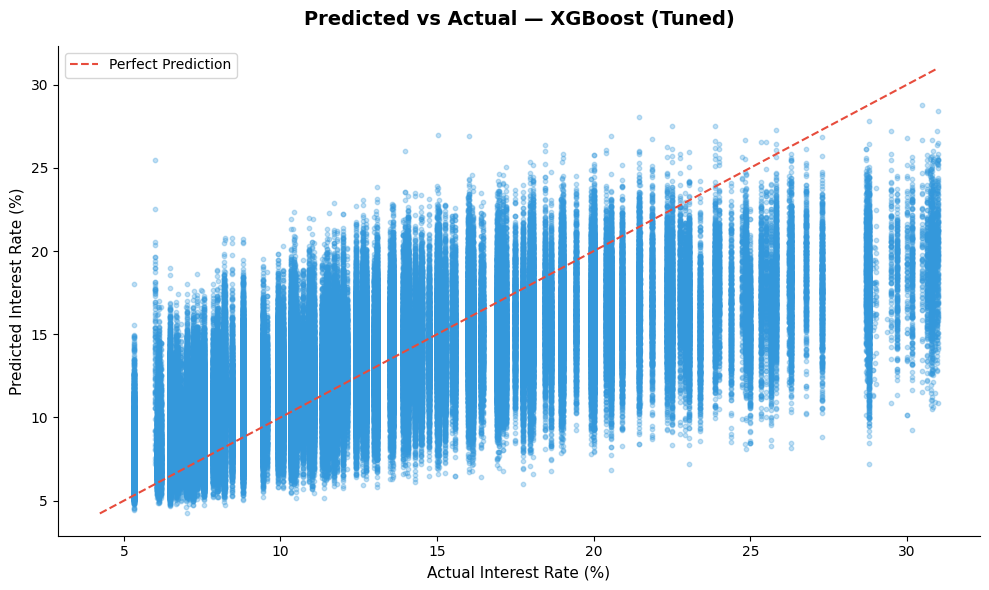

In [35]:
plot_predicted_vs_actual(
    best_xgb_pipeline, X_test, y_test, "XGBoost (Tuned)",
    save_path=FIGURES_DIR / "04_predicted_vs_actual.png"
)

### Residual Distribution

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/figures/05_xgboost_tuned_residuals.png


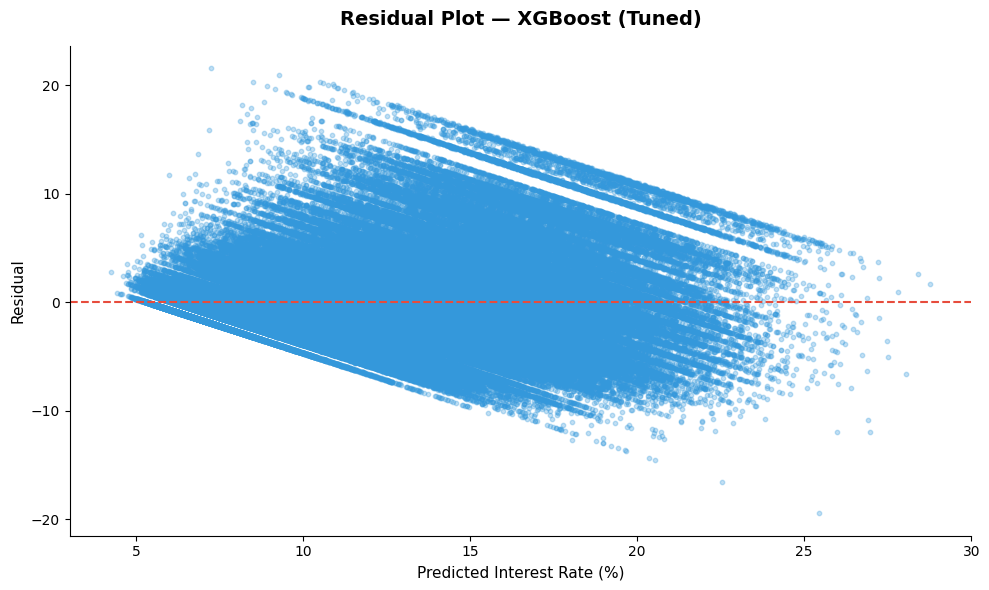

In [36]:
plot_residuals(
    best_xgb_pipeline, X_test, y_test, "XGBoost (Tuned)",
    save_path=FIGURES_DIR / "05_xgboost_tuned_residuals.png"
)

## Model Explainability

### SHAP Summary


fico_score dominates feature importance — the single strongest driver of rate prediction, consistent with its -0.416 correlation with int_rate. The utilization composite and term features follow, confirming that leverage stress and loan duration are the second tier of pricing factors. The engineered features — derogatory_score and utilization_composite — appear in the top 10, validating their construction.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/figures/06_shap_summary.png


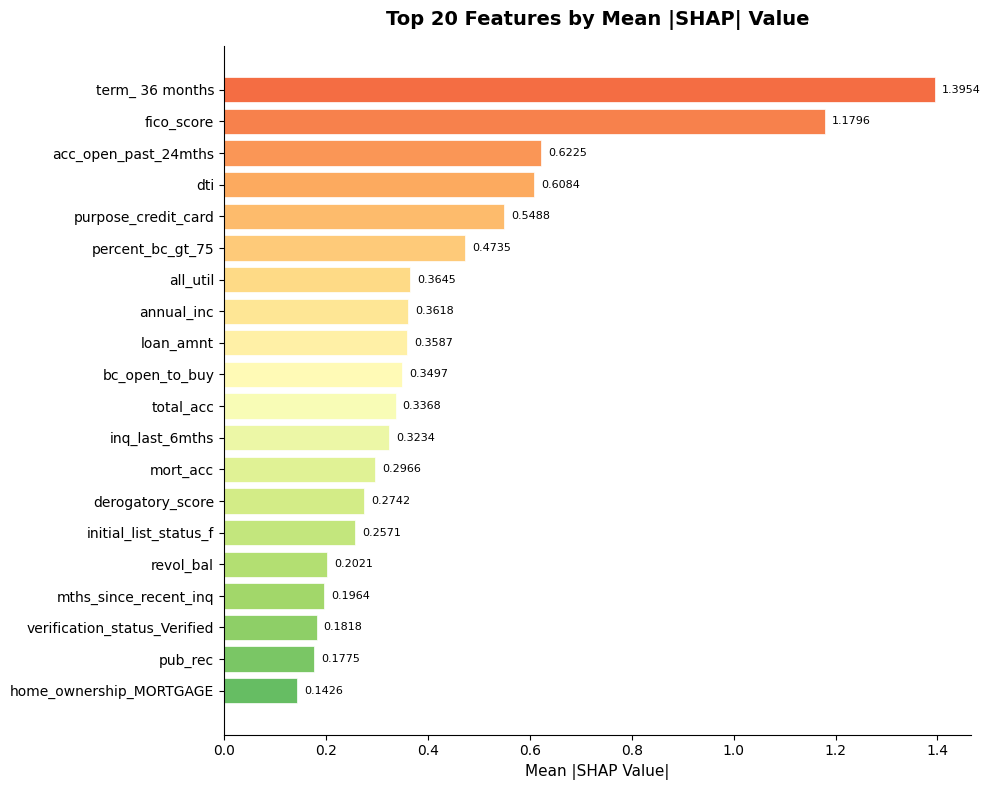

In [37]:
shap_values, X_sample, feature_names = get_shap_values(best_xgb_pipeline, X_test)

plot_shap_summary(
    shap_values, X_sample, feature_names,
    save_path=FIGURES_DIR / "06_shap_summary.png"
)

### SHAP Beeswarm


The beeswarm tells a clean pricing story. High FICO scores push strongly toward lower rates. High utilization pushes toward higher rates. Longer term (60 months) pushes toward higher rates. The directionality is exactly what a credit pricing model should show — and the fact that these patterns emerge without grade or sub_grade confirms that the pricing signal is recoverable from borrower fundamentals alone.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/pricing/models/figures/07_shap_beeswarm.png


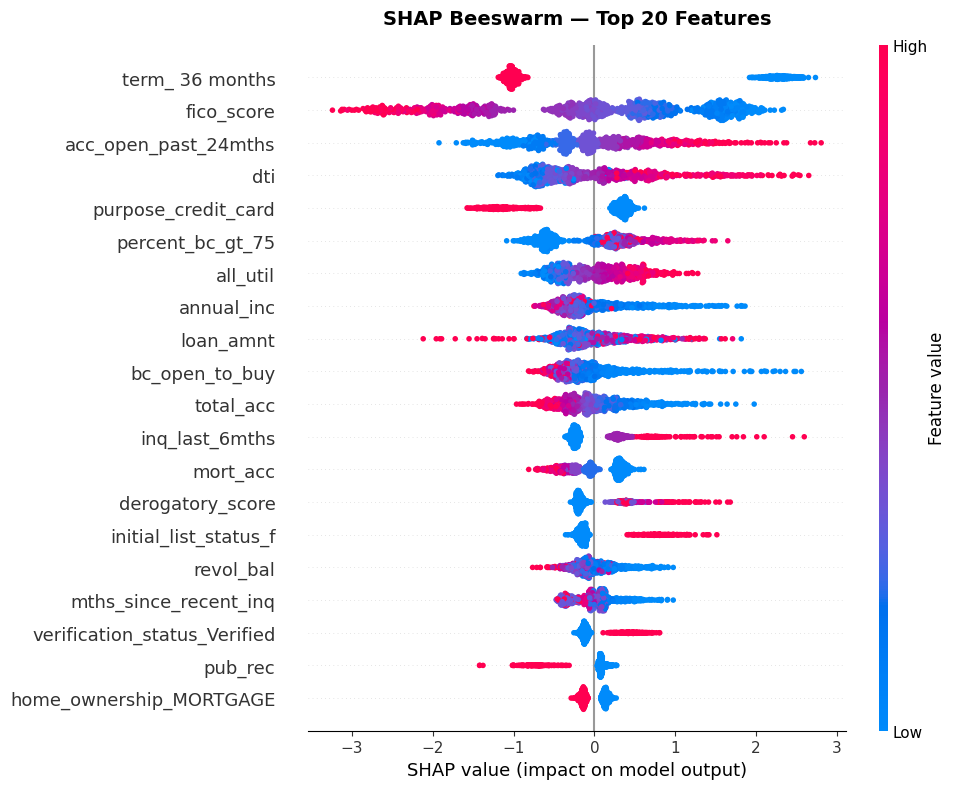

In [38]:
plot_shap_beeswarm(
    shap_values, X_sample, feature_names,
    save_path=FIGURES_DIR / "07_shap_beeswarm.png"
)

## Conclusion


This notebook reconstructed Lending Club's interest rate pricing decisions using only borrower fundamentals — no proprietary grades.

**The headline finding:** 
>A tuned XGBoost explains 48% of variance in interest rates (R² 0.4838, RMSE 3.67%) without access to Lending Club's internal risk scores. The remaining unexplained variance is largely structural — rates were assigned in discrete tiers, and no regression model can perfectly predict discrete buckets from continuous inputs.

**What drove rate prediction:**
- FICO score — the single strongest pricing factor, confirming credit quality as the foundation of Lending Club's pricing model
- Utilization composite — leverage stress as the second major factor
- Term — 60-month loans priced meaningfully higher than 36-month
- Derogatory score — delinquency and public records contributing independent signal

**The connection to notebook 1:** 
>The features that predict default and the features that predict rate are largely the same set. FICO, utilization, and derogatory history drive both. This is the expected 
result if Lending Club's pricing was genuinely risk-based — and the SHAP analyses across both notebooks confirm it.

**Limitations:**
- Discrete rate tiers create a structural ceiling on R² for any regression approach
- Grade and sub_grade exclusion removes the primary tier-assignment signal
- A classification approach predicting rate tier directly may outperform regression on this target

**What's next:**
>Notebook 3 revisits the default classification problem from notebook 1 using a neural network. The question is whether a deeper architecture can find nonlinear signal in borrower fundamentals that XGBoost missed — and whether the features that drove rate prediction in this notebook contribute additional signal to default classification.

---